# Imports

In [ ]:
!pip install torch torchvision

# === Imports ===
import os, json, math, random, time, glob, copy
from typing import Dict, List, Tuple
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from google.colab import files, drive
import zipfile

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import (
    Dataset, DataLoader, Subset, ConcatDataset, WeightedRandomSampler
)
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.metrics import (
    accuracy_score, confusion_matrix, precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score
)


ERROR: Operation cancelled by user


# Load in Datasets

## Unzip from Drive (and Check)

In [ ]:
drive.mount('/content/drive')

zip_path1 = '/content/drive/MyDrive/D-Fire.zip'
zip_path2 = '/content/drive/MyDrive/Fire Detection.v1i.yolov11.zip'
#zip_path3 = '/content/drive/MyDrive/Real Fire-Detection.zip'
zip_path4 = '/content/drive/MyDrive/SDXL Realistic Dataset.zip' # FILL IN WHEN YOU KNOW
zip_path5 = '/content/drive/MyDrive/SDXL Unrealistic Dataset.zip' # FILL IN WHEN YOU KNOW
zip_path6 = '/content/drive/MyDrive/SDXL New Unrealistic Dataset 1.zip' # FILL IN WHEN YOU KNOW
zip_path7 = '/content/drive/MyDrive/Fire Overlay Pngs.zip' # FILL IN WHEN YOU KNOW

# Real Fires

with zipfile.ZipFile(zip_path1, 'r') as zip_ref:
    zip_ref.extractall('/content/d-fire')

with zipfile.ZipFile(zip_path2, 'r') as zip_ref:
    zip_ref.extractall('/content/val-fire')

#with zipfile.ZipFile(zip_path3, 'r') as zip_ref:
    #zip_ref.extractall('/content/small-fire')

with zipfile.ZipFile(zip_path4, 'r') as zip_ref:
    zip_ref.extractall('/content/sdxl-realistic')

with zipfile.ZipFile(zip_path5, 'r') as zip_ref:
    zip_ref.extractall('/content/sdxl-unrealistic')

with zipfile.ZipFile(zip_path6, 'r') as zip_ref:
    zip_ref.extractall('/content/sdxl-new-unrealistic')

with zipfile.ZipFile(zip_path7, 'r') as zip_ref:
    zip_ref.extractall('/content/fire-overlays')




Mounted at /content/drive


## Create the Datasets

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

### Test Datasets

In [ ]:
import os
from PIL import Image
from torch.utils.data import Dataset

class FireDataset(Dataset):
    """
    Returns (image_tensor, label, img_name)
      - label = 1 if any line in the YOLO .txt has the target class_id
      - label = 0 otherwise
    Assumes images are in image_dir and labels are in label_dir with matching stems.
    """
    def __init__(self, image_dir, label_dir, fire_class_id=0, transform=None):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.fire_class_id = str(fire_class_id)
        self.transform = transform


        self.image_paths = sorted([
            os.path.join(image_dir, f)
            for f in os.listdir(image_dir)
            if f.endswith((".jpg", ".png"))
        ])

        # build the corresponding label paths by stem
        self.label_paths = [
            os.path.join(label_dir, os.path.splitext(os.path.basename(p))[0] + ".txt")
            for p in self.image_paths
        ]

        if len(self.image_paths) == 0:
            raise RuntimeError(f"No images found in {image_dir}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path  = self.image_paths[idx]
        label_path = self.label_paths[idx]
        img_name = os.path.basename(img_path)

        # load image
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        # default: no fire
        y = 0
        try:
            with open(label_path, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if not parts:
                        continue
                    if parts[0] == self.fire_class_id:
                        y = 1
                        break
        except FileNotFoundError:
            # no label file -> keep y = 0
            pass
        except Exception as e:
            print(f"!! Could not read label file: {label_path} ({e})")

        return image, y, img_name

real_test_clean = FireDataset(
    image_dir='/content/val-fire/train/images',
    label_dir='/content/val-fire/train/labels',
    fire_class_id=1,
    transform=transform
)



# Load In Results

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, glob, re, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SAVE_ROOT = "/content/drive/MyDrive/fire_proj/outputs_stage1"
MASTER_CSV = os.path.join(SAVE_ROOT, "stage1_results_master.csv")
ART_IDX    = os.path.join(SAVE_ROOT, "artifacts_index.csv")

assert os.path.exists(MASTER_CSV), f"Master CSV not found at {MASTER_CSV}"
assert os.path.exists(ART_IDX),    f"Missing {ART_IDX}"

dfm_all = pd.read_csv(MASTER_CSV)
print("Loaded master CSV with", len(dfm_all), "rows total")

dfm = dfm_all[dfm_all["condition"] == "clean"].copy()
print("Using clean condition only:", len(dfm), "rows")
display(dfm.head())


art_all = pd.read_csv(ART_IDX)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded master CSV with 1400 rows total
Using clean condition only: 200 rows


,run_id,seed,trained_epochs,condition,test_auroc,test_auprc,test_ap_lift,n_test,acc@tau*,precision@tau*,recall@tau*,f1@tau*,bal_acc@tau*,acc@0.5,precision@0.5,recall@0.5,f1@0.5,bal_acc@0.5
3,Baseline,0,0,clean,0.552853,0.878533,0.016692,8939,0.861729,0.861907,0.999740,0.925721,0.500275,0.374091,0.886405,0.313993,0.463721,0.531490
10,Baseline,1,0,clean,0.256460,0.763086,-0.098756,8939,0.860387,0.861721,0.998183,0.924946,0.499496,0.155946,0.601017,0.061397,0.111412,0.403573
17,Baseline,2,0,clean,0.480776,0.847173,-0.014669,8939,0.861394,0.861942,0.999221,0.925518,0.500420,0.510684,0.859456,0.516745,0.645428,0.494810
24,Baseline,3,0,clean,0.567879,0.883386,0.021544,8939,0.860946,0.862204,0.998183,0.925224,0.501521,0.860275,0.863990,0.994418,0.924627,0.508950
31,Baseline,4,0,clean,0.514410,0.858787,-0.003055,8939,0.560130,0.869659,0.575935,0.692956,0.518737,0.194093,0.841530,0.079958,0.146041,0.493016


# Grad CAMS


=== Synthetic_Overlays | seed 0 | indices [6802] ===


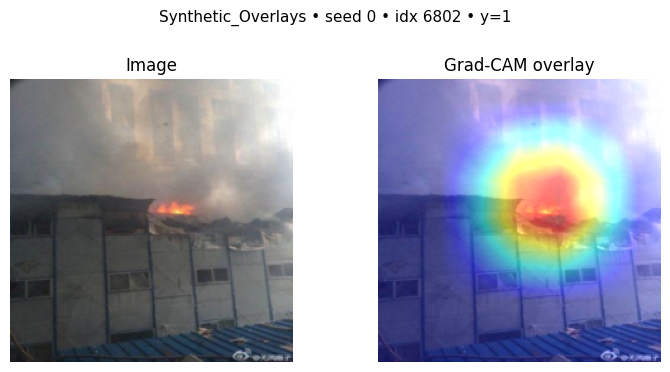


=== Synthetic_New_Unrealistic | seed 0 | indices [6487] ===


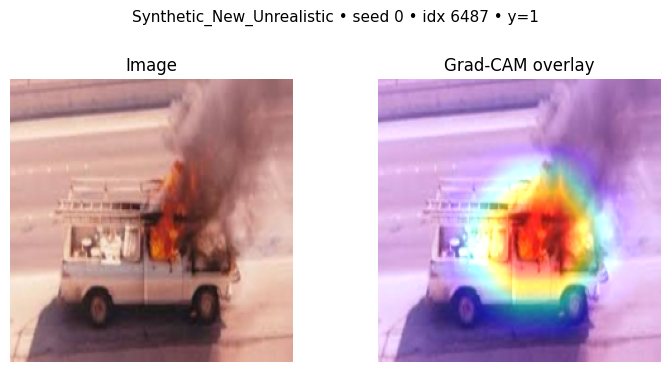


=== Baseline | seed 0 | indices [5310] ===


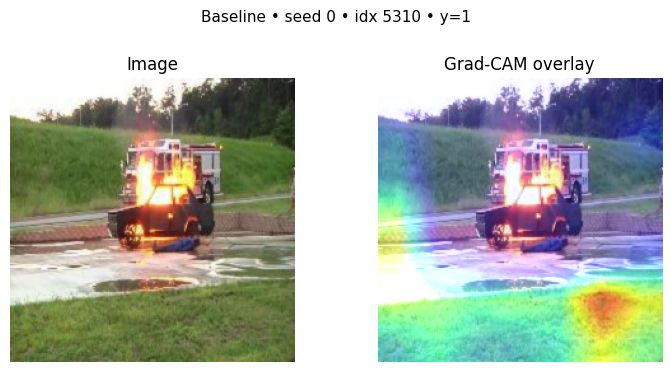


=== Synthetic_Realistic | seed 0 | indices [7504] ===


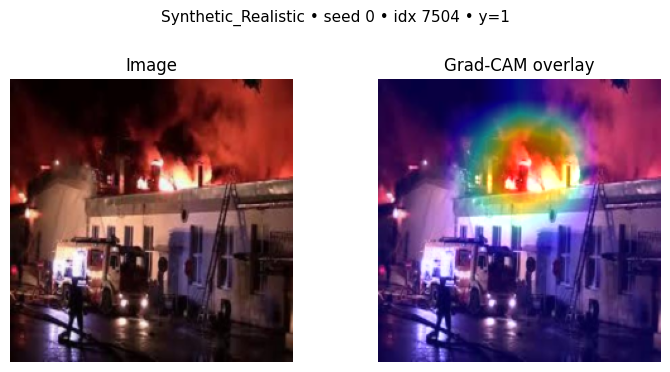


=== Synthetic_Unrealistic | seed 0 | indices [7142] ===


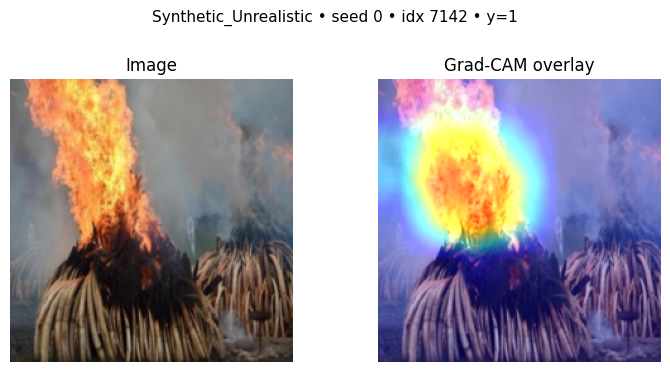

In [ ]:

import os, numpy as np, torch, torch.nn as nn, torch.nn.functional as F, random
import torchvision.transforms as T
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.models import resnet18, ResNet18_Weights
import cv2


SEED = 12
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed()

IM_SIZE = (224, 224)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

to_tensor = T.Compose([
    T.Resize(IM_SIZE),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

def denormm(t, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    mean = torch.as_tensor(mean, device=t.device).view(-1,1,1)
    std  = torch.as_tensor(std,  device=t.device).view(-1,1,1)
    return (t * std + mean).clamp(0,1)

def build_model(num_classes=2):
    m = resnet18(weights=ResNet18_Weights.DEFAULT)
    in_feats = m.fc.in_features
    m.fc = nn.Linear(in_feats, num_classes)
    return m


class ResNetGradCAMWrapper(nn.Module):
    def __init__(self, model: nn.Module, target_layer: str = "layer4"):
        super().__init__()
        self.model = model.eval()
        self._acts = None
        self._grads = None
        layer = dict(self.model.named_modules())[target_layer]
        layer.register_forward_hook(self._save_acts)
        layer.register_full_backward_hook(self._save_grads)

    def _save_acts(self, m, i, o):  self._acts = o
    def _save_grads(self, m, gi, go): self._grads = go[0]

    def get_activations(self, x): return self._acts
    def get_activations_gradient(self): return self._grads
    def forward(self, x): return self.model(x)


def superimpose_heatmap(heatmap, img):

    resized = cv2.resize(heatmap.numpy(), (img.shape[3], img.shape[2]))
    colored = cv2.applyColorMap(np.uint8(255 * resized), cv2.COLORMAP_JET)
    colored_rgb = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)

    base = denormm(img[0].cpu()).permute(1,2,0)
    overlay_scale = 0.50
    out = torch.from_numpy(colored_rgb).float() / 255.0 * overlay_scale + base
    return out.clamp(0,1)

def get_grad_cam(net, img, target_class=1):

    net.eval()

    logits = net(img)
    score = logits[:, target_class].mean()
    score.backward()

    gradients = net.get_activations_gradient()          # (1,C,h,w)
    pooled = gradients.mean(dim=[0,2,3])                # (C,)
    activs = net.get_activations(img).detach().clone()  # (1,C,h,w)
    for i in range(activs.size(1)):
        activs[:, i, :, :] *= pooled[i]

    heatmap = activs.mean(dim=1).squeeze()              # (h,w)
    heatmap = torch.maximum(heatmap, torch.tensor(0., device=heatmap.device))
    heatmap = heatmap / (heatmap.max())

    cam_img = superimpose_heatmap(heatmap.detach().cpu(), img.detach().cpu())
    return cam_img.permute(2,0,1)  # (3,H,W)


def get_artifacts(run_id: str, seed: int, condition: str = "clean"):
    rows = art_all[(art_all["run_id"] == run_id) &
                   (art_all["seed"] == seed) &
                   (art_all["condition"] == condition)].sort_values("timestamp")
    if rows.empty:
        return None, None
    return rows["npz_path"].iloc[-1], rows["ckpt_path"].iloc[-1]

def _safe_load_state(model, ckpt_path, device):
    state = torch.load(ckpt_path, map_location=device)
    if isinstance(state, dict) and "state_dict" in state:
        state = state["state_dict"]
    if hasattr(state, "state_dict"):
        state = state.state_dict()
    model.load_state_dict(state)
    return model


def show_gradcam_from_npz_indices(run_id, seed, indices, device=None, target_layer="layer4"):

    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    npz_path, ckpt_path = get_artifacts(run_id, seed, condition="clean")

    data   = np.load(npz_path)
    paths  = data["paths"]
    y_true = data["y_true"].astype(int)

    model = build_model().to(device).eval()
    model = _safe_load_state(model, ckpt_path, device)
    net   = ResNetGradCAMWrapper(model, target_layer=target_layer)

    results = []
    for idx in indices:
        assert 0 <= idx < len(paths), f"Index {idx} out of range for {run_id} (len={len(paths)})"
        impath = str(paths[idx])

        pil = Image.open(impath).convert("RGB")
        x = to_tensor(pil).unsqueeze(0).to(device)
        cam = get_grad_cam(net, x)
        raw = denormm(x[0]).detach().cpu()
        y   = int(y_true[idx])

        # --- show (no save)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.5, 3.6))
        fig.suptitle(f"{run_id} • seed {seed} • idx {idx} • y={y}", y=1.02, fontsize=11)
        ax1.imshow(raw.permute(1,2,0).numpy()); ax1.set_title("Image"); ax1.axis("off")
        ax2.imshow(cam.permute(1,2,0).numpy()); ax2.set_title("Grad-CAM overlay"); ax2.axis("off")
        plt.tight_layout(); plt.show(); plt.close(fig)

        results.append((raw, cam, y, idx, impath))
    return results



RUNS_AND_IDXS = {
    "Synthetic_Overlays":        [6802],  # overlays
    "Synthetic_New_Unrealistic": [6487],  # low fidelity
    "Baseline":                  [5310],  # baseline #5310
    "Synthetic_Realistic":       [7504],  # realistic
    "Synthetic_Unrealistic":     [7142],  # cartoon
}

device = "cuda" if torch.cuda.is_available() else "cpu"
all_outputs = {}

for run_id, idxs in RUNS_AND_IDXS.items():
    seed = 0
    print(f"\n=== {run_id} | seed {seed} | indices {idxs} ===")
    out = show_gradcam_from_npz_indices(run_id, seed, idxs, device=device, target_layer="layer4")
    all_outputs[run_id] = out

